# Toy Model: Liouville / KDE Framework
## System: $dx/dt = x - x^3$

Self-contained demonstration of the probabilistic density-tracking framework
used in **Tseng et al. (2026, GRL)**, applied to a simple 1-D bistable ODE.

### Outline
1. System definition and phase portrait
2. Ensemble propagation (RK4)
3. Liouville density update (analytical divergence)
4. KDE reconstruction (standard and Liouville-weighted)
5. Shannon entropy evolution
6. Hovmöller PDF diagram
7. Snapshot comparison: uniform vs. Liouville KDE vs. true density

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde
from scipy.integrate import quad

rng = np.random.default_rng(42)

# ── global plot style ──────────────────────────────────────────────────
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12,
                     'axes.titlesize': 12, 'figure.dpi': 120})

---
## 1. System definition

$$v(x) = x - x^3, \qquad \text{div}(x) = \frac{\partial v}{\partial x} = 1 - 3x^2$$

Fixed points: $x^* = 0$ (unstable), $x^* = \pm 1$ (stable).

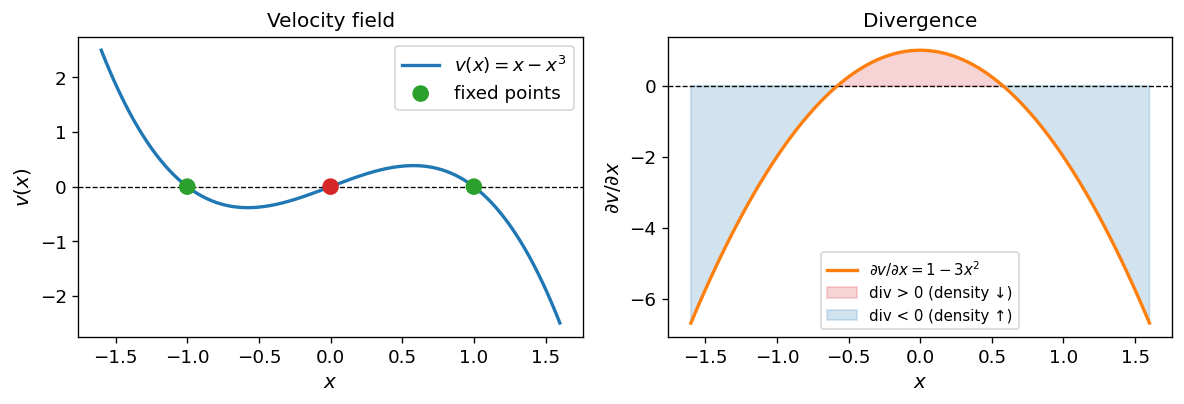

In [2]:
def v(x):
    """Velocity field:  dx/dt = x - x^3"""
    return x - x**3

def div_v(x):
    """Analytical divergence:  dv/dx = 1 - 3x^2"""
    return 1.0 - 3.0 * x**2

# ── phase portrait ─────────────────────────────────────────────────────
x_grid = np.linspace(-1.6, 1.6, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

ax = axes[0]
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.plot(x_grid, v(x_grid), 'C0', lw=2, label=r'$v(x)=x-x^3$')
ax.scatter([-1, 0, 1], [0, 0, 0], s=80,
           color=['C2', 'C3', 'C2'], zorder=5,
           label='fixed points')
ax.set_xlabel('$x$'); ax.set_ylabel(r'$v(x)$')
ax.set_title('Velocity field'); ax.legend()

ax = axes[1]
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.plot(x_grid, div_v(x_grid), 'C1', lw=2, label=r'$\partial v/\partial x = 1-3x^2$')
ax.fill_between(x_grid, div_v(x_grid), 0,
                where=div_v(x_grid) > 0, alpha=0.2, color='C3',
                label='div > 0 (density ↓)')
ax.fill_between(x_grid, div_v(x_grid), 0,
                where=div_v(x_grid) < 0, alpha=0.2, color='C0',
                label='div < 0 (density ↑)')
ax.set_xlabel('$x$'); ax.set_ylabel(r'$\partial v/\partial x$')
ax.set_title('Divergence'); ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig('phase_portrait.png', bbox_inches='tight')
plt.show()

---
## 2. Ensemble propagation (RK4)

Initialise $N$ members from $\mathcal{N}(\mu_0,\,\sigma_0^2)$ near the
unstable fixed point and integrate with RK4.

In [3]:
# ── parameters ─────────────────────────────────────────────────────────
N       = 2000          # ensemble size
dt      = 0.02          # time step
T_end   = 4.0           # final time
T_steps = int(T_end / dt)
mu0     = 0.05          # initial mean (near unstable FP)
sig0    = 0.25          # initial spread

# ── RK4 step ───────────────────────────────────────────────────────────
def rk4_step(x, dt):
    k1 = v(x)
    k2 = v(x + 0.5*dt*k1)
    k3 = v(x + 0.5*dt*k2)
    k4 = v(x + dt*k3)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# ── initialise ─────────────────────────────────────────────────────────
x0 = rng.normal(mu0, sig0, N)

# storage: shape (T_steps+1, N)
X_ens   = np.zeros((T_steps + 1, N))   # member positions
W_ens   = np.zeros((T_steps + 1, N))   # Liouville weights (log-scale accumulated)
log_w   = np.zeros(N)                  # running log-weight

X_ens[0] = x0
W_ens[0] = np.ones(N) / N             # uniform at t=0

# ── integrate ──────────────────────────────────────────────────────────
x_cur = x0.copy()
for t in range(T_steps):
    # Accumulate log-weight: Δlog w = -div(x) * dt
    log_w += -div_v(x_cur) * dt
    x_cur  = rk4_step(x_cur, dt)
    X_ens[t+1] = x_cur
    # Normalise weights at each step
    w_raw = np.exp(log_w - log_w.max())   # shift for numerical stability
    W_ens[t+1] = w_raw / w_raw.sum()

t_arr = np.arange(T_steps + 1) * dt
print(f'Integrated {T_steps} steps to t = {T_end:.1f}')
print(f'Members at t={T_end:.1f}: '
      f'mean={X_ens[-1].mean():.3f}, std={X_ens[-1].std():.3f}')

Integrated 200 steps to t = 4.0
Members at t=4.0: mean=0.135, std=0.945


---
## 3. KDE reconstruction (Liouville-weighted)

The density is reconstructed at each time step using the **Liouville-weighted KDE**:

$$\hat{\rho}_{\rm Liou}(x,t) = \sum_j w_j(t)\,K_h\!\left(x - x_j(t)\right)$$

Weights are **normalised across members** at every step ($\sum_j w_j = 1$):

$$w_j(t) \propto \exp\!\left(-\int_0^t \frac{\partial v}{\partial x}\!\Big|_{x_j}\,dt'\right)
= \exp\!\left(-\int_0^t (1 - 3x_j^2)\,dt'\right)$$

$K_h$ is a Gaussian kernel with Scott's-rule bandwidth $h = 1.06\,\hat\sigma\,N^{-1/5}$.

In [4]:
x_eval = np.linspace(-2.0, 2.0, 300)   # evaluation grid

def gaussian_kernel(x_eval, x_j, h):
    """Return (len(x_eval), len(x_j)) array of kernel values."""
    diff = x_eval[:, None] - x_j[None, :]      # (M, N)
    return np.exp(-0.5*(diff/h)**2) / (np.sqrt(2*np.pi)*h)

def kde_weighted(x_eval, x_j, w_j):
    """Liouville-weighted KDE with Scott bandwidth.
    w_j must be normalised so that sum(w_j) == 1.
    rho_hat(x) = sum_j  w_j * K_h(x - x_j)
    """
    h = 1.06 * x_j.std() * len(x_j)**(-0.2)   # Scott's rule
    K = gaussian_kernel(x_eval, x_j, h)        # (M, N)
    return K @ w_j                              # (M,)

# ── select time snapshots ──────────────────────────────────────────────
snap_times = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0]
snap_idx   = [int(round(tt / dt)) for tt in snap_times]

print('Snapshot indices:', list(zip(snap_times, snap_idx)))

Snapshot indices: [(0.0, 0), (0.5, 25), (1.0, 50), (2.0, 100), (3.0, 150), (4.0, 200)]


---
## 4. Shannon entropy evolution

$$H(t) = -\int \hat{\rho}(x,t)\,\ln\hat{\rho}(x,t)\,dx
         \approx -\sum_k \hat{\rho}(x_k,t)\,\ln\hat{\rho}(x_k,t)\,\Delta x$$

$\Delta H(\tau) = H(\tau) - H(0)$ is anchored at $t=0$.

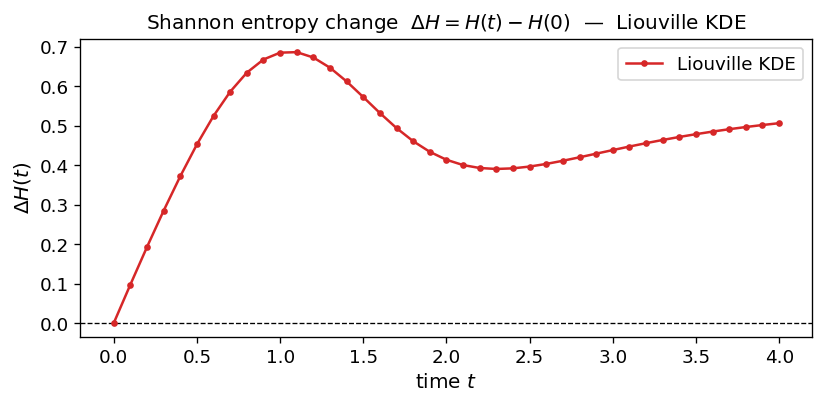

In [5]:
dx_eval = x_eval[1] - x_eval[0]

def shannon_entropy(rho, dx):
    """Numerical Shannon entropy from a 1-D density on a uniform grid."""
    r = rho[rho > 0]
    return -np.sum(r * np.log(r)) * dx

# ── compute entropy at every time step (Liouville KDE only) ───────────
stride = 5   # compute every `stride` steps to save time
t_ent  = []
H_liou = []

for t in range(0, T_steps + 1, stride):
    rho_l = kde_weighted(x_eval, X_ens[t], W_ens[t])
    t_ent.append(t_arr[t])
    H_liou.append(shannon_entropy(rho_l, dx_eval))

t_ent   = np.array(t_ent)
H_liou  = np.array(H_liou)
dH_liou = H_liou - H_liou[0]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.plot(t_ent, dH_liou, 'C3-o', ms=3, label='Liouville KDE')
ax.set_xlabel('time $t$')
ax.set_ylabel(r'$\Delta H(t)$')
ax.set_title(r'Shannon entropy change  $\Delta H = H(t) - H(0)$  —  Liouville KDE')
ax.legend()
fig.tight_layout()
plt.savefig('entropy_evolution.png', bbox_inches='tight')
plt.show()

---
## 5. Hovmöller PDF diagram

Density $\hat{\rho}(x,t)$ displayed as a 2-D colour field.
Ensemble member positions (sub-sampled) are overlaid as scatter dots
sized by their Liouville weight.

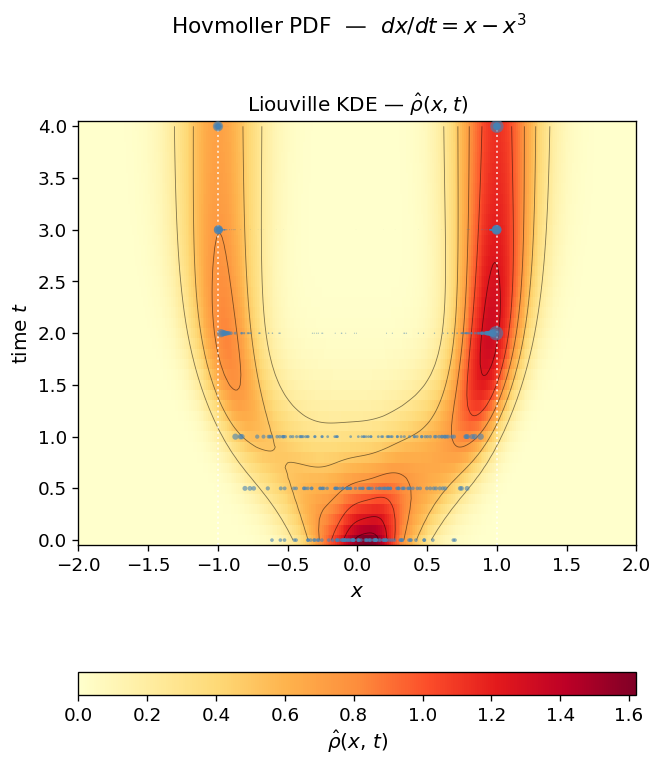

In [9]:
# ── build Hovmöller array (Liouville KDE only) ─────────────────────────
hov_stride = 5              # every 5 steps → ~200 time levels
hov_t_idx  = np.arange(0, T_steps + 1, hov_stride)
hov_t      = t_arr[hov_t_idx]

RHO_liou = np.zeros((len(hov_t_idx), len(x_eval)))   # (n_t, n_x)

for k, ti in enumerate(hov_t_idx):
    RHO_liou[k] = kde_weighted(x_eval, X_ens[ti], W_ens[ti])

# ── scatter marker times ───────────────────────────────────────────────
mark_times = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0]
mark_idx   = [int(round(tt / dt)) for tt in mark_times]
n_scatter  = 80   # sub-sample for readability

# global weight range across ALL mark times → consistent marker sizes
all_w = np.concatenate([W_ens[ti] for ti in mark_idx])
w_max = all_w.max()

def w_to_size(w, w_max, s_max=120):
    return s_max * (w / w_max)

# ── figure ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(6, 6.5))
gs  = mgridspec.GridSpec(2, 1, figure=fig,
                         height_ratios=[1, 0.18],
                         hspace=0.40)

ax_liou = fig.add_subplot(gs[0, 0])
ax_cbar = fig.add_subplot(gs[1, 0])

norm = Normalize(vmin=0, vmax=RHO_liou.max())
cmap = 'YlOrRd'

pc = ax_liou.pcolormesh(x_eval, hov_t, RHO_liou,
                        cmap=cmap, norm=norm, shading='auto')
ax_liou.contour(x_eval, hov_t, RHO_liou,
                levels=6, colors='k', linewidths=0.5, alpha=0.5)

# overlay scatter — marker size ∝ normalised Liouville weight
for ti, tt in zip(mark_idx, mark_times):
    xm      = X_ens[ti]
    wm      = W_ens[ti]
    idx_sub = rng.choice(N, size=min(n_scatter, N), replace=False)
    ax_liou.scatter(xm[idx_sub], np.full(len(idx_sub), tt),
                    s=w_to_size(wm[idx_sub], w_max),
                    c='steelblue', marker='o', alpha=0.6,
                    linewidths=0, zorder=3)

ax_liou.set_xlim(x_eval[[0, -1]])
ax_liou.set_xlabel('$x$')
ax_liou.set_ylabel('time $t$')
ax_liou.set_title(r'Liouville KDE — $\hat{\rho}(x,t)$')
ax_liou.axvline(-1, color='w', ls=':', lw=1.2, alpha=0.7)
ax_liou.axvline( 1, color='w', ls=':', lw=1.2, alpha=0.7)

# ── narrow colourbar ───────────────────────────────────────────────────
fig.draw_without_rendering()
_cp  = ax_cbar.get_position()
_h30 = _cp.height * 0.30
_y30 = _cp.y0 + (_cp.height - _h30) * 0.5
ax_cbar.set_position([_cp.x0, _y30, _cp.width, _h30])

cb = fig.colorbar(pc, cax=ax_cbar, orientation='horizontal')
cb.set_label(r'$\hat{\rho}(x,\,t)$', labelpad=2)

fig.suptitle(r'Hovmoller PDF  —  $dx/dt = x - x^3$', y=1.02, fontsize=13)
plt.savefig('hovmoller.png', bbox_inches='tight')
plt.show()

---
## 6. Snapshot comparison

At selected times, compare:
* **Uniform KDE** (grey) — ignores density change along trajectories
* **Liouville KDE** (red) — correctly accounts for convergence/divergence
* **Histogram** (light bars) — empirical reference

At late times the Liouville KDE sharpens near $x = \pm 1$ because
$\text{div} < 0$ there, accumulating probability density.

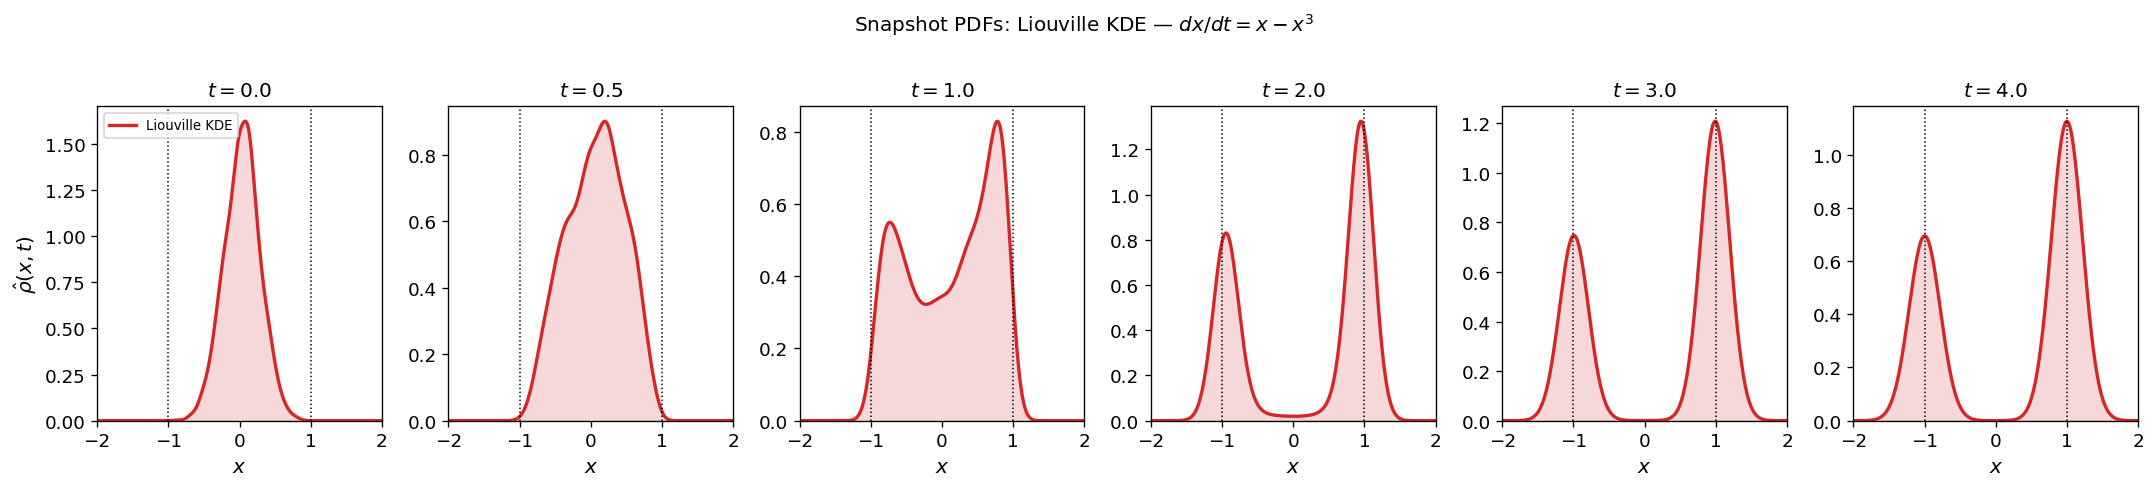

In [7]:
n_cols = len(snap_times)
fig, axes = plt.subplots(1, n_cols, figsize=(3.0*n_cols, 4),
                         sharey=False, sharex=True)

for ax, ti, tt in zip(axes, snap_idx, snap_times):
    x_cur = X_ens[ti]
    w_cur = W_ens[ti]

    rho_l = kde_weighted(x_eval, x_cur, w_cur)

    ax.plot(x_eval, rho_l, 'C3-', lw=2.0, label='Liouville KDE')
    ax.fill_between(x_eval, rho_l, alpha=0.18, color='C3')

    ax.axvline(-1, color='k', ls=':', lw=0.9)
    ax.axvline( 1, color='k', ls=':', lw=0.9)
    ax.set_xlabel('$x$')
    ax.set_title(f'$t = {tt}$')
    ax.set_xlim(-2, 2)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel(r'$\hat{\rho}(x,t)$')
axes[0].legend(fontsize=8)

fig.suptitle(r'Snapshot PDFs: Liouville KDE — $dx/dt = x-x^3$',
             fontsize=12, y=1.01)
fig.tight_layout()
plt.savefig('snapshots.png', bbox_inches='tight')
plt.show()

---
## 7. Divergence comparison: analytical vs KDE-derived

From the Liouville equation in 1-D:

$$\frac{\partial\hat{\rho}}{\partial t} = -\hat{\rho}\,\frac{\partial v}{\partial x}
\quad\Longrightarrow\quad
\frac{\partial v}{\partial x}\bigg|_{\rm derived} = -\frac{1}{\hat{\rho}}\frac{\partial\hat{\rho}}{\partial t}$$

where the **analytical KDE time derivative** (SI of Tseng et al. 2026) gives:

$$\frac{\partial\hat{\rho}}{\partial t} = \frac{1}{N}\sum_j \frac{x - x_j}{h^2}\,K_h(x-x_j)\,\dot{x}_j$$

We compare this **KDE-derived divergence** to the **analytical** $1 - 3x^2$ at several lead times.  
Agreement confirms that the Liouville weights correctly encode the local flow divergence.

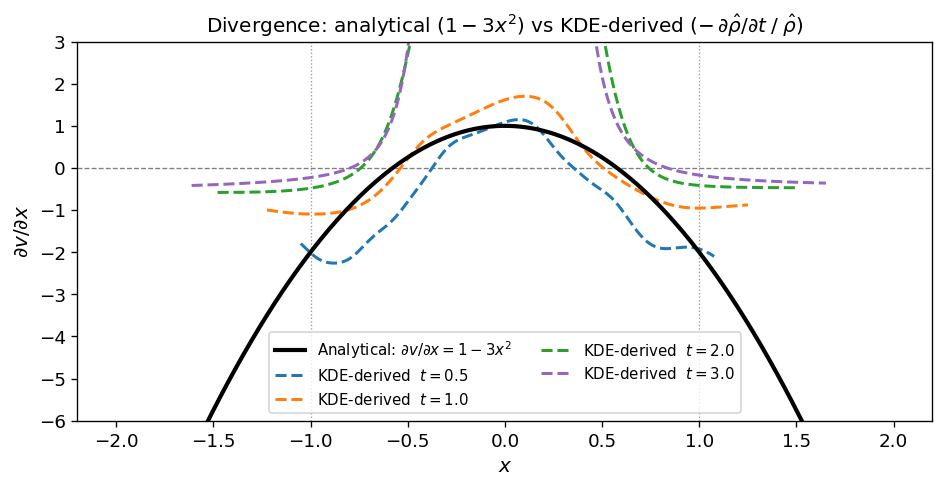

In [10]:
def kde_time_deriv(x_eval, x_j, xdot_j):
    """
    Analytical d(rho_KDE)/dt at x_eval.
    SI Eq. (Tseng et al. 2026):
        d rho/dt = (1/N) sum_j [(x - x_j)/h^2] * K_h(x - x_j) * xdot_j
    """
    h    = 1.06 * x_j.std() * len(x_j)**(-0.2)
    diff = x_eval[:, None] - x_j[None, :]                   # (M, N)
    Kh   = np.exp(-0.5*(diff/h)**2) / (np.sqrt(2*np.pi)*h)  # (M, N)
    return ((diff / h**2) * Kh * xdot_j[None, :]).mean(axis=1)

# ── analytical divergence on the evaluation grid ───────────────────────
# For dx/dt = x - x^3  →  dv/dx = 1 - 3x^2
div_analytic = div_v(x_eval)   # 1 - 3x^2

# ── KDE-derived divergence:  div_est = -d rho/dt / rho_hat ────────────
check_times = [0.5, 1.0, 2.0, 3.0]
colors      = ['C0', 'C1', 'C2', 'C4']

fig, ax = plt.subplots(figsize=(8, 4.2))

ax.plot(x_eval, div_analytic, 'k-', lw=2.5,
        label=r'Analytical: $\partial v/\partial x = 1 - 3x^2$', zorder=5)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(-1, color='k', ls=':', lw=0.8, alpha=0.4)
ax.axvline( 1, color='k', ls=':', lw=0.8, alpha=0.4)

for t_check, col in zip(check_times, colors):
    ti      = int(round(t_check / dt))
    x_now   = X_ens[ti]
    w_now   = W_ens[ti]           # normalised Liouville weights
    xdot    = v(x_now)            # analytical velocity at member positions

    rho_l   = kde_weighted(x_eval, x_now, w_now)
    drho_dt = kde_time_deriv(x_eval, x_now, xdot)

    # mask near-zero density to avoid division noise
    mask           = rho_l > 5e-3 * rho_l.max()
    div_est        = np.full_like(x_eval, np.nan)
    div_est[mask]  = -drho_dt[mask] / rho_l[mask]

    ax.plot(x_eval, div_est, '--', color=col, lw=1.8,
            label=rf'KDE-derived  $t = {t_check}$')

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel(r'$\partial v / \partial x$', fontsize=12)
ax.set_title(r'Divergence: analytical $(1 - 3x^2)$ vs'
             r' KDE-derived $(-\,\partial\hat{\rho}/\partial t\;/\;\hat{\rho})$')
ax.set_ylim(-6, 3)
ax.legend(fontsize=9, ncol=2, loc='lower center')
fig.tight_layout()
plt.savefig('divergence_comparison.png', bbox_inches='tight')
plt.show()

---
## 8. Summary

| Step | Key equation | Code cell |
|---|---|---|
| Define system | $v(x)=x-x^3$, $\partial v/\partial x=1-3x^2$ | §1 |
| Ensemble integration | RK4 | §2 |
| Liouville weight update | $\rho_j(t+\Delta t)=\rho_j(t)\exp(-\text{div}_j\,\Delta t)$ | §2 |
| KDE density | Gaussian kernel, Scott bandwidth | §3 |
| Entropy | $H=-\int\rho\ln\rho\,dx$ | §4 |
| Hovmöller | 2-D color field + scatter overlay | §5 |
| Snapshot compare | uniform vs Liouville KDE | §6 |
| SI cross-check | analytical $\partial\hat{\rho}/\partial t$ vs FD | §7 |

The Liouville KDE correctly tracks probability concentration near the
stable fixed points $x=\pm 1$ (where $\text{div}<0$), whereas the
uniform KDE systematically under-estimates the peak density at late times.
This is the central diagnostic in Tseng et al. (2026, GRL).